In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
# Load the dataset 
data = pd.read_csv(r'C:\Users\ShankarGautam\Downloads\ICANTraining\project_work\insurance.csv')


In [68]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [69]:
#Generate a new dataframe with the data trimmed to two decimal places
columns_to_round = ['bmi', 'charges']
data_trimmed = data.copy()
data_trimmed[columns_to_round] = data_trimmed[columns_to_round].round(2)

In [70]:
data_trimmed.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [71]:
data_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [72]:
data_trimmed.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.92
max,64.00,53.13,5.00,63770.43


In [73]:
data_trimmed.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

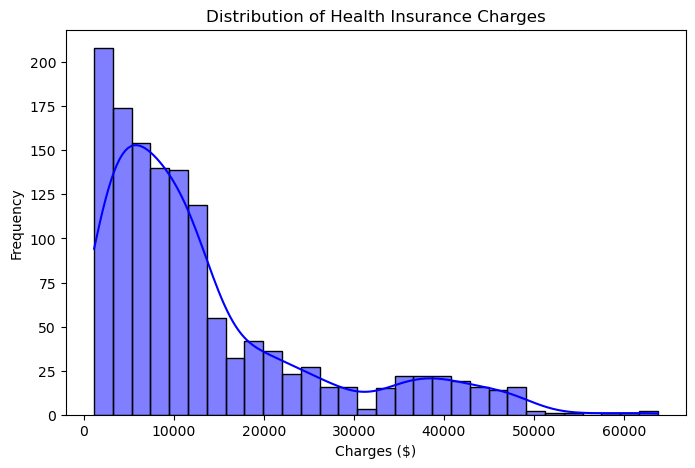

In [74]:
# Visualize the distribution of the target variable (Charges)
plt.figure(figsize=(8, 5))
sns.histplot(data_trimmed['charges'], kde=True, color='blue')
plt.title('Distribution of Health Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

C:\Users\ShankarGautam\AppData\Local\Temp\ipykernel_31292\3512265092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=data_trimmed, palette=['lightblue','salmon'])


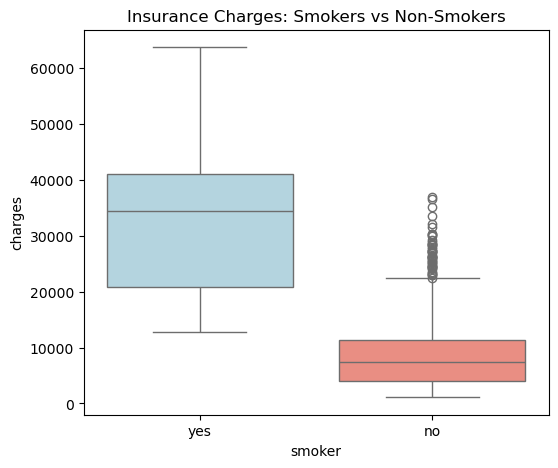

In [75]:
# Analyze the impact of categorical factors (e.g., Smoking vs Charges)
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=data_trimmed, palette=['lightblue','salmon'])
plt.title('Insurance Charges: Smokers vs Non-Smokers')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode 'sex' and 'smoker' only if they're still categorical strings
if data_trimmed["sex"].dtype == "O":
    le_sex = LabelEncoder()
    data_trimmed["sex"] = le_sex.fit_transform(data_trimmed["sex"])
if data_trimmed["smoker"].dtype == "O":
    le_smoker = LabelEncoder()
    data_trimmed["smoker"] = le_smoker.fit_transform(data_trimmed["smoker"])

# One-hot encode 'region' only if the original column exists; otherwise ensure dummies exist and are numeric
if "region" in data_trimmed.columns:
    data_trimmed = pd.get_dummies(data_trimmed, columns=["region"], drop_first=True)
else:
    region_cols = [c for c in data_trimmed.columns if c.startswith("region_")]
    if not region_cols:
        raise KeyError(
            "No 'region' column or 'region_' dummy columns found in data_trimmed."
        )
    # convert boolean dummies to integers for modeling
    data_trimmed[region_cols] = data_trimmed[region_cols].astype(int)

# Separate features and target
X = data_trimmed.drop("charges", axis=1)
y = data_trimmed["charges"]


In [131]:
data_trimmed.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.92,0,0,1
1,18,1,33.77,1,0,1725.55,0,1,0
2,28,1,33.00,3,0,4449.46,0,1,0
3,33,1,22.70,0,0,21984.47,1,0,0
4,32,1,28.88,0,0,3866.86,1,0,0


In [132]:
data_trimmed.corr()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.020856,0.109275,0.042469,-0.025019,0.299008,-0.000407,-0.011642,0.010016
sex,-0.020856,1.000000,0.046377,0.017163,0.076185,0.057292,-0.011156,0.017117,-0.004184
bmi,0.109275,0.046377,1.000000,0.012766,0.003744,0.198331,-0.135954,0.270017,-0.006222
children,0.042469,0.017163,0.012766,1.000000,0.007673,0.067998,0.024806,-0.023066,0.021914
smoker,-0.025019,0.076185,0.003744,0.007673,1.000000,0.787251,-0.036945,0.068498,-0.036945
charges,0.299008,0.057292,0.198331,0.067998,0.787251,1.000000,-0.039905,0.073982,-0.043210
region_northwest,-0.000407,-0.011156,-0.135954,0.024806,-0.036945,-0.039905,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,0.017117,0.270017,-0.023066,0.068498,0.073982,-0.346265,1.000000,-0.346265
region_southwest,0.010016,-0.004184,-0.006222,0.021914,-0.036945,-0.043210,-0.320829,-0.346265,1.000000


<Axes: >

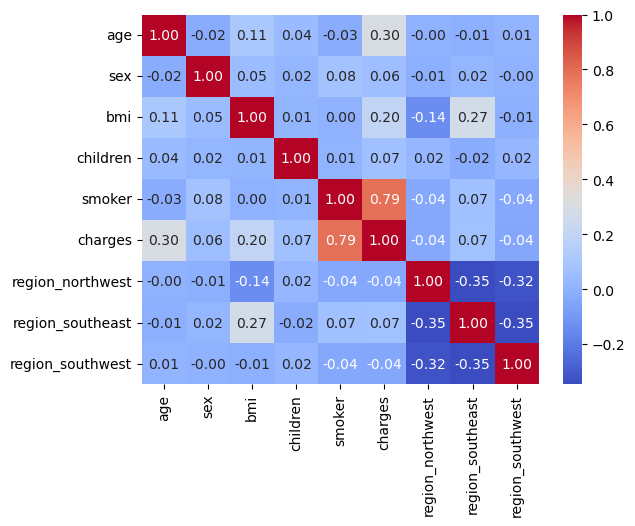

In [133]:
sns.heatmap(data_trimmed.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [130]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [115]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [116]:
# MODEL 1: Linear Regression (Baseline)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, -18.58, 337.08,...,-371.02,-657.82,-809.78]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [117]:
# Predict on test data
lr_preds = lr_model.predict(X_test)

In [124]:
# Evaluate
from sklearn.metrics import mean_squared_error


print("--- Linear Regression Performance ---")
print(f"R² Score (Accuracy): {r2_score(y_test, lr_preds):.4f}")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, lr_preds):.2f}\n")

--- Linear Regression Performance ---
R² Score (Accuracy): 0.7836
Mean Absolute Error (MAE): $4181.07



In [126]:
# MODEL 2: Random Forest Regressor (Advanced)
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
rf_preds = rf_model.predict(X_test)

# Evaluate
print("--- Random Forest Performance ---")
print(f"R² Score (Accuracy): {r2_score(y_test, rf_preds):.4f}")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, rf_preds):.2f}")

--- Random Forest Performance ---
R² Score (Accuracy): 0.8649
Mean Absolute Error (MAE): $2559.27


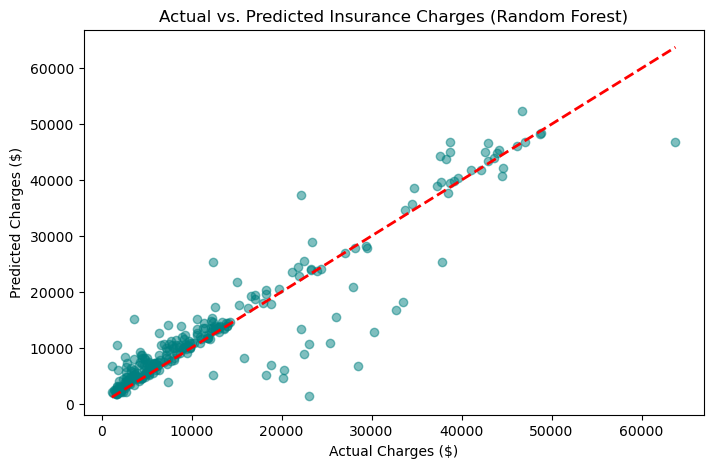

In [127]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Insurance Charges (Random Forest)')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.show()